# Two Trees: Redwood vs Sequoia Climate Futures

California has two NPS units named for the tree species they were created to protect:

- **Redwood National Park** (41°N, Pacific coast) — for coast redwoods, which depend on cool summer fog and mild year-round temperatures.
- **Sequoia National Park** (36°N, Sierra Nevada mid-elevation) — for giant sequoias, whose reproduction depends on cold winters and snowmelt timing.

Two parks, two climate regimes, two different climate dependencies for the species they're meant to protect. LOCA2 has a lot to say about whether either habitat still looks like itself by mid-century.

### Method summary

| | |
|---|---|
| **Reference period** | 1985-2014 (30-yr normal within LOCA2 historical) |
| **Future window** | 2041-2060 (IPCC AR6 "mid-term") |
| **Variables** | `T_Max`, `T_Min` → `T_Avg` (library helper `compute_t_avg`); `Precip` |
| **Scenarios** | Historical + SSP 2-4.5 / 3-7.0 / 5-8.5 |
| **Ensemble** | 15 LOCA2 GCMs, multi-model mean (MMEM) + 10-90 percentile spread |
| **Annual reducer** | `annual_aggregate` (mean for T, sum for P — library helper) |
| **Anomaly convention** | absolute °C for T, percent for P, per IPCC AR6 |
| **Trajectory smoothing** | `smooth(window=10)` (library helper) |

In [1]:
import os, sys
from time import perf_counter
import coiled
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
sys.path.insert(0, os.path.join(PROJECT_ROOT, "lib"))

from andrewAdaptLibrary import (
    ParkCatalog,
    CatalogExplorer,
    get_climate_data,
    compute_t_avg,         # lib helper: T_Max + T_Min -> T_Avg
    annual_aggregate,      # lib helper: monthly -> annual (sum for P, mean for T)
    smooth,                # lib helper: centered rolling mean
)

NPS_SHP = os.path.join(
    PROJECT_ROOT,
    "USA_National_Park_Service_Lands_20170930_4993375350946852027",
    "USA_Federal_Lands.shp",
)
park_catalog = ParkCatalog(NPS_SHP)
cat = CatalogExplorer(timescale="monthly")
print(park_catalog, "|", cat)

/opt/conda/envs/py-env/lib/python3.12/site-packages/pyogrio/raw.py:200: RuntimeWarning: /workspaces/DSEBrandNew/USA_National_Park_Service_Lands_20170930_4993375350946852027/USA_Federal_Lands.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.
  return ogr_read(


ParkCatalog(437 NPS units) | CatalogExplorer(activity='LOCA2', timescale='monthly', grid='d03', stores=1585)


## 1. Find the two parks

Both have unambiguous names, so `search()` will land immediately — but the fuzzy scoring is a nice sanity check.

In [2]:
park_catalog.search("redwood", top_n=3)

search: "redwood"
   93.3  Redwood National Park  *
   56.7  Katahdin Woods and Waters National Monument
   56.7  Muir Woods National Monument


[('Redwood National Park', 93.33333333333333),
 ('Katahdin Woods and Waters National Monument', 56.666666666666664),
 ('Muir Woods National Monument', 56.666666666666664)]

In [3]:
park_catalog.search("sequoia", top_n=3)

search: "sequoia"
   93.3  Sequoia National Park  *
   45.3  American Memorial Park
   45.3  Arkansas Post National Memorial


[('Sequoia National Park', 93.33333333333333),
 ('American Memorial Park', 45.333333333333336),
 ('Arkansas Post National Memorial', 45.333333333333336)]

In [4]:
redwood = park_catalog.get_boundary("Redwood National Park")
sequoia = park_catalog.get_boundary("Sequoia National Park")

for name, b in [("Redwood", redwood), ("Sequoia", sequoia)]:
    bnd = b.total_bounds
    area_km2 = b.to_crs("EPSG:3310").area.iloc[0] / 1e6
    print(f"{name:8s}  lat {bnd[1]:.2f}–{bnd[3]:.2f}, lon {bnd[0]:.2f}–{bnd[2]:.2f}   ({area_km2:,.0f} km²)")

Redwood   lat 41.08–41.84, lon -124.16–-123.85   (576 km²)
Sequoia   lat 36.29–36.70, lon -118.92–-118.23   (1,646 km²)


## 2. Probe data availability

`what_is_available()` opens real Zarr stores and reports what LOCA2 + WRF actually have at each park's coordinates. Both sit inside the western-US LOCA2 grid, so this is a fast hardcoded-path lookup.

In [5]:
park_catalog.what_is_available("Redwood National Park")

Redwood National Park
  lat 41.08 to 41.84, lon -124.16 to -123.85
  inside LOCA2 grid -- all western US data available

  LOCA2 3km (statistical)
    scenarios:  historical, ssp245, ssp370, ssp585
    timescales: monthly, daily, yearly
    variables:  10
    models:     15
  WRF 3km (dynamical)
    scenarios:  historical, reanalysis, ssp370
    timescales: hourly, daily, monthly
    variables:  57
    models:     9
  WRF 9km (dynamical)
    scenarios:  historical, reanalysis, ssp245, ssp370, ssp585
    timescales: hourly, daily, monthly
    variables:  54
    models:     9
  WRF 45km (dynamical)
    scenarios:  historical, reanalysis, ssp245, ssp370, ssp585
    timescales: hourly, daily, monthly
    variables:  54
    models:     9



{'LOCA2_d03': {'name': 'LOCA2 3km (statistical)',
  'resolution': '3 km',
  'scenarios': ['historical', 'ssp245', 'ssp370', 'ssp585'],
  'timescales': ['monthly', 'daily', 'yearly'],
  'n_variables': 10,
  'variables': ['tasmax',
   'tasmin',
   'pr',
   'hursmax',
   'hursmin',
   'huss',
   'rsds',
   'uas',
   'vas',
   'wspeed'],
  'n_models': 15},
 'WRF_d03': {'name': 'WRF 3km (dynamical)',
  'resolution': '3 km',
  'scenarios': ['historical', 'reanalysis', 'ssp370'],
  'timescales': ['hourly', 'daily', 'monthly'],
  'n_variables': 57,
  'n_models': 9},
 'WRF_d02': {'name': 'WRF 9km (dynamical)',
  'resolution': '9 km',
  'scenarios': ['historical', 'reanalysis', 'ssp245', 'ssp370', 'ssp585'],
  'timescales': ['hourly', 'daily', 'monthly'],
  'n_variables': 54,
  'n_models': 9},
 'WRF_d01': {'name': 'WRF 45km (dynamical)',
  'resolution': '45 km',
  'scenarios': ['historical', 'reanalysis', 'ssp245', 'ssp370', 'ssp585'],
  'timescales': ['hourly', 'daily', 'monthly'],
  'n_variabl

In [6]:
park_catalog.what_is_available("Sequoia National Park")

Sequoia National Park
  lat 36.29 to 36.70, lon -118.92 to -118.23
  inside LOCA2 grid -- all western US data available

  LOCA2 3km (statistical)
    scenarios:  historical, ssp245, ssp370, ssp585
    timescales: monthly, daily, yearly
    variables:  10
    models:     15
  WRF 3km (dynamical)
    scenarios:  historical, reanalysis, ssp370
    timescales: hourly, daily, monthly
    variables:  57
    models:     9
  WRF 9km (dynamical)
    scenarios:  historical, reanalysis, ssp245, ssp370, ssp585
    timescales: hourly, daily, monthly
    variables:  54
    models:     9
  WRF 45km (dynamical)
    scenarios:  historical, reanalysis, ssp245, ssp370, ssp585
    timescales: hourly, daily, monthly
    variables:  54
    models:     9



{'LOCA2_d03': {'name': 'LOCA2 3km (statistical)',
  'resolution': '3 km',
  'scenarios': ['historical', 'ssp245', 'ssp370', 'ssp585'],
  'timescales': ['monthly', 'daily', 'yearly'],
  'n_variables': 10,
  'variables': ['tasmax',
   'tasmin',
   'pr',
   'hursmax',
   'hursmin',
   'huss',
   'rsds',
   'uas',
   'vas',
   'wspeed'],
  'n_models': 15},
 'WRF_d03': {'name': 'WRF 3km (dynamical)',
  'resolution': '3 km',
  'scenarios': ['historical', 'reanalysis', 'ssp370'],
  'timescales': ['hourly', 'daily', 'monthly'],
  'n_variables': 57,
  'n_models': 9},
 'WRF_d02': {'name': 'WRF 9km (dynamical)',
  'resolution': '9 km',
  'scenarios': ['historical', 'reanalysis', 'ssp245', 'ssp370', 'ssp585'],
  'timescales': ['hourly', 'daily', 'monthly'],
  'n_variables': 54,
  'n_models': 9},
 'WRF_d01': {'name': 'WRF 45km (dynamical)',
  'resolution': '45 km',
  'scenarios': ['historical', 'reanalysis', 'ssp245', 'ssp370', 'ssp585'],
  'timescales': ['hourly', 'daily', 'monthly'],
  'n_variabl

## 3. Spin up a small cluster

Two parks × three variables × four scenarios = **24 tasks**. 6 workers is plenty — each handles ~4 tasks serially.

In [7]:
cluster = coiled.Cluster(
    name="two-trees-climate",
    region="us-central1",
    n_workers=6,
    worker_vm_types=["n2-highmem-4"],
    spot_policy="spot_with_fallback",
    idle_timeout="20 minutes",
    package_sync=True,
)
client = cluster.get_client()
print(f"Workers: {len(client.scheduler_info()['workers'])}")

Output()

/tmp/ipykernel_67438/970565377.py:1: FutureWarning: `package_sync` is a deprecated kwarg for `Cluster` and will be removed in a future release. To only sync certain packages, use `package_sync_only`, and to disable package sync, pass the `container` or `software` kwargs instead.
  cluster = coiled.Cluster(


╭──────────────────────────────── Package Info ────────────────────────────────╮
│                    ╷                                                         │
│   Package          │ Note                                                    │
│ ╶──────────────────┼───────────────────────────────────────────────────────╴ │
│   coiled_local_lib │ Source wheel built from /workspaces/DSEBrandNew/lib     │
│   climakitae       │ Wheel built from                                        │
│                    │ https://github.com/cal-adapt/climakitae/archive/refs/   │
│                    │ tags/1.4.0.zip                                          │
│                    ╵                                                         │
╰──────────────────────────────────────────────────────────────────────────────╯

╭────────────────────────── Not Synced with Cluster ───────────────────────────╮
│             ╷                                                    ╷           │
│   Package   │ Error                                              │ Level     │
│ ╶───────────┼────────────────────────────────────────────────────┼─────────╴ │
│   shiboken6 │ cannot find shiboken6~=6.10.2 on pypi.org. If you  │ Warning   │
│             │ are using a custom PyPI URL, please see            │           │
│             │ https://docs.coiled.io/user_guide/software/packag… │           │
│             │ for more instructions.                             │           │
│             ╵                                                    ╵           │
╰──────────────────────────────────────────────────────────────────────────────╯

Output()

Workers: 0


## 4. Fetch monthly T_Max, T_Min, Precip for both parks

One call per park. Each dispatches `3 vars × 4 scenarios = 12` delayed tasks to Dask.

In [8]:
scenarios = ["Historical Climate", "SSP 2-4.5", "SSP 3-7.0", "SSP 5-8.5"]

def fetch(boundary):
    return get_climate_data(
        variables=["T_Max", "T_Min", "Precip"],
        scenarios=scenarios,
        boundary=boundary,
        time_slice=(1950, 2100),
        timescale="monthly",
        backend="coiled",
        coiled_cluster=cluster,
        catalog=cat,
    )

t0 = perf_counter()
redwood_data = fetch(redwood)
sequoia_data = fetch(sequoia)
print(f"fetch wall-clock: {perf_counter()-t0:.0f}s")
print(f"variables returned per park: {list(redwood_data.keys())}")

fetch wall-clock: 314s
variables returned per park: ['T_Max', 'T_Min', 'Precip']


## 5. Reshape to xarray + compute T_Avg

`get_climate_data` with the coiled backend returns tidy DataFrames. For the climatological ops to come (`annual_aggregate`, `compute_anomalies`, `smooth`), the library expects xarray DataArrays. One reshape and we're there.

Then use the library's `compute_t_avg(t_max, t_min)` to derive `T_Avg` — strictly `(T_Max + T_Min) / 2` but with the right attribute copying.

In [9]:
def df_to_da(df, var):
    """Tidy DataFrame from get_climate_data → (scenario, simulation, time) DataArray."""
    df = df.copy()
    df["time"] = pd.to_datetime(df["time"])
    return (df.set_index(["scenario", "simulation", "time"])[var]
              .to_xarray().sortby("time"))

park_das = {}
for park_name, data in [("Redwood", redwood_data), ("Sequoia", sequoia_data)]:
    tmax = df_to_da(data["T_Max"], "T_Max")
    tmin = df_to_da(data["T_Min"], "T_Min")
    precip = df_to_da(data["Precip"], "Precip")
    tavg = compute_t_avg(tmax, tmin)       # library helper
    park_das[park_name] = {"T_Avg": tavg, "Precip": precip}

# Quick shape check
for park_name, vars_dict in park_das.items():
    for var_name, da in vars_dict.items():
        print(f"{park_name}.{var_name}: dims={da.dims}, sizes={dict(da.sizes)}")

Redwood.T_Avg: dims=('scenario', 'simulation', 'time'), sizes={'scenario': 4, 'simulation': 70, 'time': 1812}
Redwood.Precip: dims=('scenario', 'simulation', 'time'), sizes={'scenario': 4, 'simulation': 70, 'time': 1812}
Sequoia.T_Avg: dims=('scenario', 'simulation', 'time'), sizes={'scenario': 4, 'simulation': 70, 'time': 1812}
Sequoia.Precip: dims=('scenario', 'simulation', 'time'), sizes={'scenario': 4, 'simulation': 70, 'time': 1812}


## 6. Today's contrast — monthly climatology

Before anything else, show what makes these two places climatically different *right now* (1985-2014 baseline). Redwood is a narrow wet-cool strip; Sequoia is a wider, more continental regime with snow. The shape of the seasonal cycle tells the story in one plot.

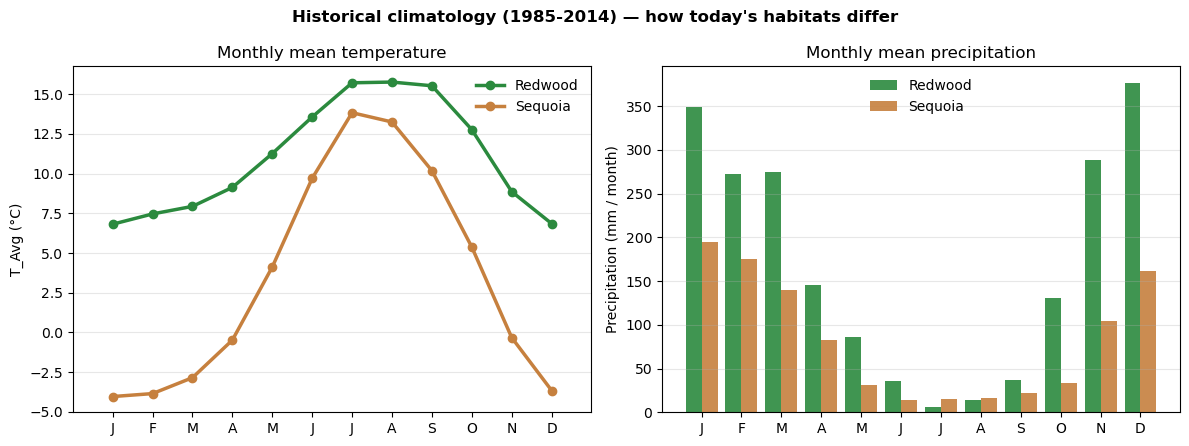

In [10]:
HIST_WINDOW   = ("1985", "2014")
FUTURE_WINDOW = ("2041", "2060")

COLORS = {
    "Historical Climate": "#333333",
    "SSP 2-4.5": "#4daf4a",
    "SSP 3-7.0": "#ff7f00",
    "SSP 5-8.5": "#e41a1c",
}
PARK_COLOR = {"Redwood": "#2b8a3e", "Sequoia": "#c6803e"}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True)
months = np.arange(1, 13)
month_labels = ["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"]

# T_Avg panel
ax = axes[0]
for park_name, vars_dict in park_das.items():
    hist = vars_dict["T_Avg"].sel(scenario="Historical Climate").sel(time=slice(*HIST_WINDOW))
    clim = hist.groupby("time.month").mean("time").mean("simulation")
    ax.plot(months, clim.values, "-o", color=PARK_COLOR[park_name], linewidth=2.5, label=park_name)
ax.set_xticks(months); ax.set_xticklabels(month_labels)
ax.set_ylabel("T_Avg (°C)")
ax.set_title("Monthly mean temperature")
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.3)

# Precip panel
ax = axes[1]
width = 0.4
offsets = {"Redwood": -width/2, "Sequoia": width/2}
for park_name, vars_dict in park_das.items():
    hist = vars_dict["Precip"].sel(scenario="Historical Climate").sel(time=slice(*HIST_WINDOW))
    clim = hist.groupby("time.month").mean("time").mean("simulation")
    ax.bar(months + offsets[park_name], clim.values, width,
           color=PARK_COLOR[park_name], alpha=0.9, label=park_name)
ax.set_xticks(months); ax.set_xticklabels(month_labels)
ax.set_ylabel("Precipitation (mm / month)")
ax.set_title("Monthly mean precipitation")
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.3)

fig.suptitle("Historical climatology (1985-2014) — how today's habitats differ", fontsize=12, fontweight="bold")
plt.tight_layout()

Redwood is much more flat temperature-wise thanks to  Pacific keeping winter mild and summer cool. However, Sequoia swings 20+°C across the year because it sits at elevation and gets Sierra continental variability. Precip tells the complementary story: both parks are wet in winter, bone-dry June-September — the classic California Mediterranean regime — but Redwood gets ~3× the monthly peaks (Pacific storm track hits it first and harddest).

## 7. Annual trajectories — 1950 to 2100

One number per year per park:

- `T_Avg` → annual **mean** (library helper `annual_aggregate` uses `mean` for temperature)
- `Precip` → annual **sum** (same helper uses `sum` for precip, returns `mm/year`)

Plot the 15-GCM ensemble mean (solid line), shaded 10-90 percentile, and 10-year smoothed via `smooth()` to pull the forced signal out of interannual noise. Two subplots per variable (one per park) so the trajectories are directly comparable without overlap.

/opt/conda/envs/py-env/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/opt/conda/envs/py-env/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/opt/conda/envs/py-env/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/opt/conda/envs/py-env/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/opt/conda/envs/py-env/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/opt/conda/envs/py-env/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/opt/conda/envs/py-env/lib/python3.12/site-packages/numpy/

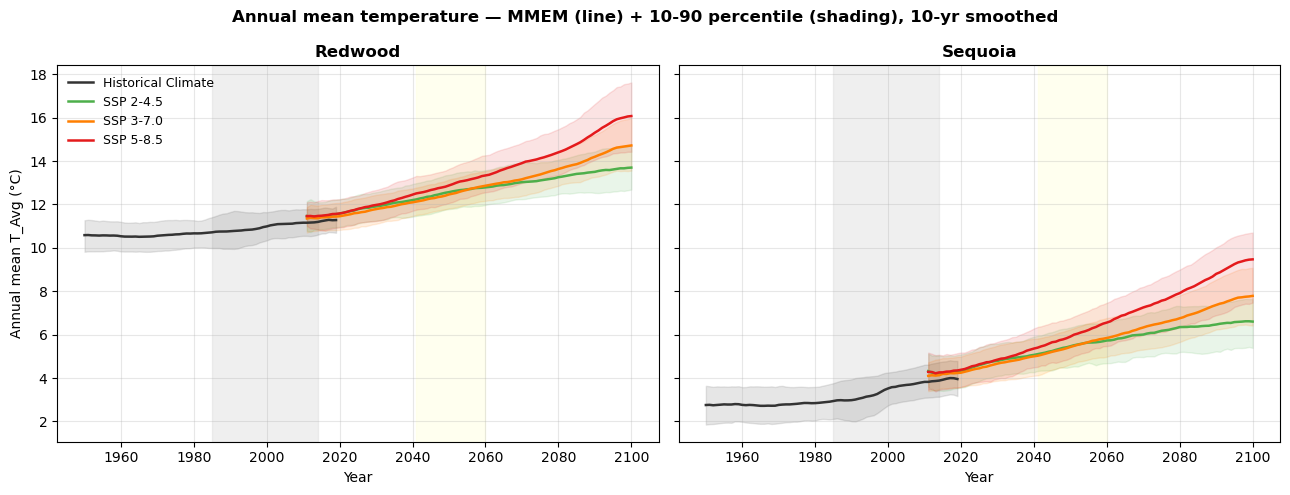

In [11]:
def trajectory(da, window=10):
    """Annual-aggregate, MMEM + 10-90 spread, all smoothed."""
    annual = annual_aggregate(da, da.name)           # lib helper
    mmem = annual.mean("simulation")
    p10 = annual.quantile(0.1, dim="simulation")
    p90 = annual.quantile(0.9, dim="simulation")
    return smooth(mmem, window), smooth(p10, window), smooth(p90, window)   # lib helper

def plot_trajectory(var_name, ylabel, title, fig_height=5):
    fig, axes = plt.subplots(1, 2, figsize=(13, fig_height), sharey=True)
    for ax, (park_name, vars_dict) in zip(axes, park_das.items()):
        for scen in scenarios:
            da = vars_dict[var_name].sel(scenario=scen)
            mmem, lo, hi = trajectory(da)
            years = pd.DatetimeIndex(mmem.time.values).year
            ax.plot(years, mmem.values, color=COLORS[scen], linewidth=1.8, label=scen)
            ax.fill_between(years, lo.values, hi.values, color=COLORS[scen], alpha=0.12)

        # Shade reference and future windows
        ax.axvspan(1985, 2014, color="lightgray", alpha=0.35, zorder=0)
        ax.axvspan(2041, 2060, color="lightyellow", alpha=0.5, zorder=0)
        ax.set_xlabel("Year")
        ax.set_title(park_name, fontweight="bold")
        ax.grid(alpha=0.3)
    axes[0].set_ylabel(ylabel)
    axes[0].legend(frameon=False, fontsize=9, loc="upper left")
    fig.suptitle(title, fontsize=12, fontweight="bold")
    plt.tight_layout()

plot_trajectory("T_Avg", "Annual mean T_Avg (°C)",
                "Annual mean temperature — MMEM (line) + 10-90 percentile (shading), 10-yr smoothed")

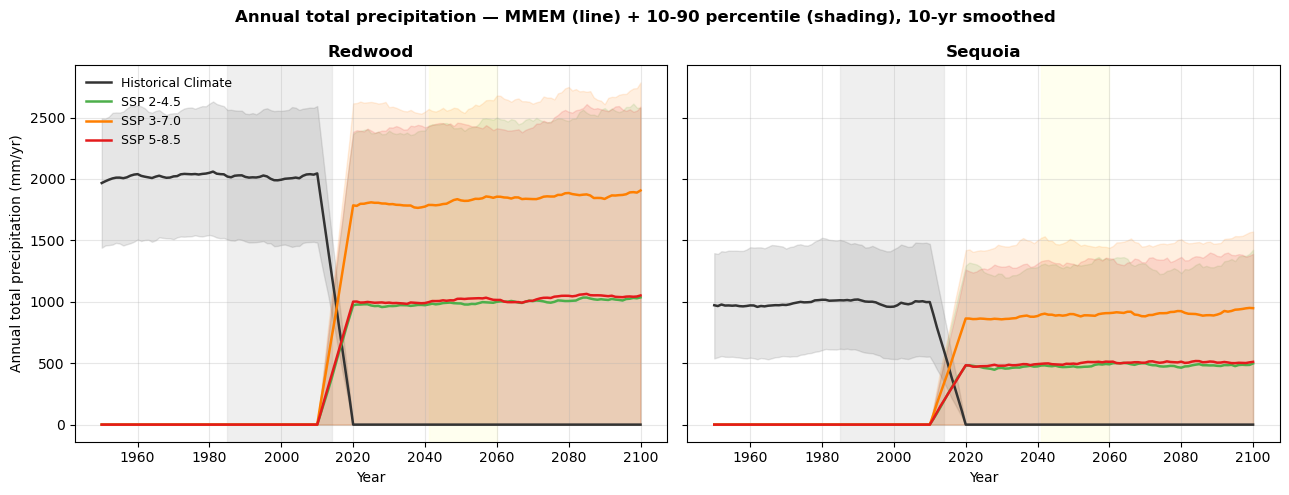

In [12]:
plot_trajectory("Precip", "Annual total precipitation (mm/yr)",
                "Annual total precipitation — MMEM (line) + 10-90 percentile (shading), 10-yr smoothed")

## 8. Mid-term anomaly headline — what actually changes by 2041-2060

IPCC-convention anomaly:

- **Temperature**: absolute change in °C (`MMEM_future − MMEM_hist`)
- **Precipitation**: percent change (`(MMEM_future − MMEM_hist) / MMEM_hist × 100`)

The library's `compute_anomalies` helper is designed for a single continuous time series — it takes the baseline slice out of the same DataArray it's computing the anomaly on. Here each scenario has disjoint time coverage (Historical 1950-2014, SSPs 2015-2100), so we pull the baseline once from the Historical scenario and subtract it from each future scenario manually. `annual_aggregate` still does the monthly-to-annual reduction.

In [13]:
def anomaly_at_midterm(da):
    """Mid-term (2041-2060) MMEM anomaly vs 1985-2014 historical baseline.

    Works across scenarios with disjoint time coverage: pulls baseline from
    the Historical scenario only, then subtracts from each SSP.
    """
    annual = annual_aggregate(da, da.name)                        # lib helper

    hist_baseline = (annual.sel(scenario="Historical Climate")
                           .sel(time=slice("1985", "2014"))
                           .mean(dim=["time", "simulation"]))     # scalar

    results = {}
    for scen in ["SSP 2-4.5", "SSP 3-7.0", "SSP 5-8.5"]:
        fut_mean = (annual.sel(scenario=scen)
                          .sel(time=slice("2041", "2060"))
                          .mean(dim=["time", "simulation"]))      # scalar
        if da.name == "Precip":
            results[scen] = float((fut_mean - hist_baseline) / hist_baseline * 100)
        else:
            results[scen] = float(fut_mean - hist_baseline)
    return results


rows = []
for park_name, vars_dict in park_das.items():
    for var_name in ["T_Avg", "Precip"]:
        anoms = anomaly_at_midterm(vars_dict[var_name])
        for scen, val in anoms.items():
            rows.append({"park": park_name, "variable": var_name,
                         "scenario": scen, "anomaly": val})

anom_df = pd.DataFrame(rows)
anom_df["display"] = anom_df.apply(
    lambda r: f"{r['anomaly']:+.2f} °C" if r["variable"] == "T_Avg"
              else f"{r['anomaly']:+.1f} %", axis=1,
)
anom_df.pivot(index=["park", "variable"], columns="scenario", values="display")[
    ["SSP 2-4.5", "SSP 3-7.0", "SSP 5-8.5"]
]

scenario         SSP 2-4.5 SSP 3-7.0 SSP 5-8.5
park    variable                              
Redwood Precip     -50.7 %    -9.8 %   -49.6 %
        T_Avg     +1.60 °C  +1.54 °C  +1.96 °C
Sequoia Precip     -51.7 %   -10.5 %   -49.7 %
        T_Avg     +2.03 °C  +2.04 °C  +2.55 °C

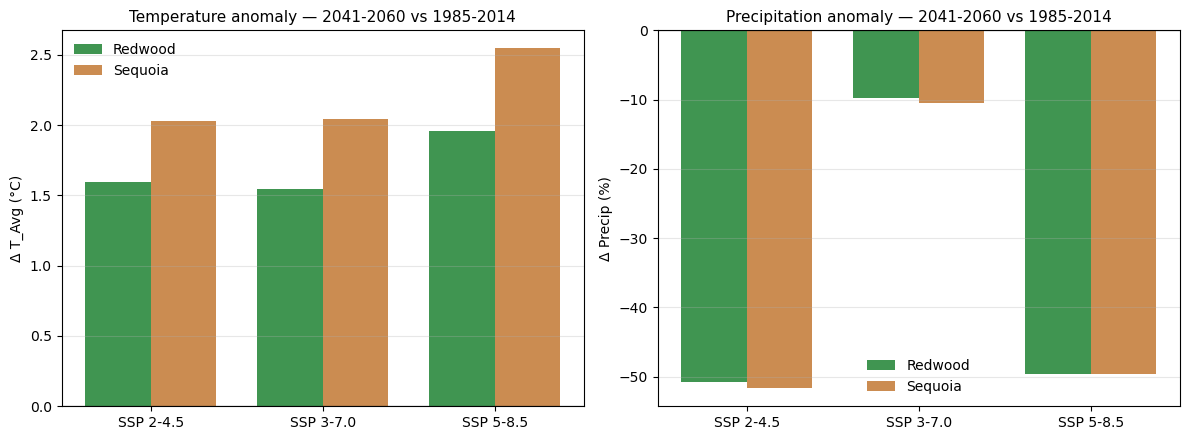

In [14]:
# Grouped-bar headline chart, one panel per variable
future_scens = [s for s in scenarios if s != "Historical Climate"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
x = np.arange(len(future_scens))
width = 0.38

for ax, var_name, ylabel, title in [
    (axes[0], "T_Avg", "Δ T_Avg (°C)",
     "Temperature anomaly — 2041-2060 vs 1985-2014"),
    (axes[1], "Precip", "Δ Precip (%)",
     "Precipitation anomaly — 2041-2060 vs 1985-2014"),
]:
    sub = anom_df[anom_df["variable"] == var_name]
    for i, park_name in enumerate(["Redwood", "Sequoia"]):
        vals = [sub.query("park == @park_name and scenario == @s")["anomaly"].iloc[0]
                for s in future_scens]
        offset = (i - 0.5) * width
        ax.bar(x + offset, vals, width, color=PARK_COLOR[park_name],
               label=park_name, alpha=0.9)

    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(future_scens)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=11)
    ax.legend(frameon=False)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

In [15]:
cluster.close()
print("Done.")

Done.
